# Machine Learning-Based Stroke Prediction: Evaluating the Impact of Data Preprocessing Techniques

## 02_MissingValues: Missing-Value Handling Comparison

### Research Objective

The objective of this notebook is to compare missing-value handling techniques and identify the most appropriate strategy for preparing the stroke prediction dataset. The analysis focuses on the `bmi` variable because the exploratory analysis showed that missingness is concentrated in this clinically relevant feature.

The four methods compared are row deletion, mean imputation, median imputation, and KNN imputation. No machine learning models are trained in this notebook; the comparison is limited to data quality, distributional preservation, sample retention, and methodological suitability.

## 1. Import Libraries and Define Paths

This notebook saves processed datasets to `data/processed/`, figures to `results/figures/`, and summary tables to `results/tables/`. The output files support reproducibility and allow later notebooks to use the selected missing-value strategy without repeating the exploratory comparison.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "healthcare-dataset-stroke-data.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Dataset and Inspect BMI Missingness

The raw dataset is loaded directly from the `data` directory. BMI is expected to contain missing values. Before comparing imputation methods, it is necessary to quantify how much BMI information is missing and whether missingness appears to differ across clinically meaningful groups.

In [2]:
df = pd.read_csv(DATA_PATH)
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")

print(f"Dataset shape: {df.shape}")
print(f"BMI missing values: {df['bmi'].isna().sum()}")
print(f"BMI missing percentage: {df['bmi'].isna().mean() * 100:.2f}%")
display(df.head())

Dataset shape: (5110, 12)
BMI missing values: 201
BMI missing percentage: 3.93%


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. Analyse BMI Missingness

BMI missingness is examined overall and by selected patient characteristics. If missingness differs substantially across groups, deleting incomplete observations may distort the dataset. This is especially important in healthcare prediction because biased preprocessing can affect downstream model fairness and clinical interpretability.

In [3]:
df_missing = df.copy()
df_missing["bmi_missing"] = df_missing["bmi"].isna()
df_missing["age_group"] = pd.cut(
    df_missing["age"],
    bins=[0, 18, 35, 50, 65, 82],
    labels=["0-18", "19-35", "36-50", "51-65", "66+"]
)

missing_overall = pd.DataFrame({
    "metric": ["Total records", "BMI missing count", "BMI missing percentage"],
    "value": [len(df), df["bmi"].isna().sum(), round(df["bmi"].isna().mean() * 100, 2)]
})

missing_by_stroke = df_missing.groupby("stroke", observed=False)["bmi_missing"].agg(["count", "sum", "mean"]).reset_index()
missing_by_stroke["missing_percentage"] = (missing_by_stroke["mean"] * 100).round(2)
missing_by_stroke = missing_by_stroke.drop(columns="mean")

missing_by_age_group = df_missing.groupby("age_group", observed=False)["bmi_missing"].agg(["count", "sum", "mean"]).reset_index()
missing_by_age_group["missing_percentage"] = (missing_by_age_group["mean"] * 100).round(2)
missing_by_age_group = missing_by_age_group.drop(columns="mean")

missing_by_gender = df_missing.groupby("gender", observed=False)["bmi_missing"].agg(["count", "sum", "mean"]).reset_index()
missing_by_gender["missing_percentage"] = (missing_by_gender["mean"] * 100).round(2)
missing_by_gender = missing_by_gender.drop(columns="mean")

missing_overall.to_csv(TABLES_DIR / "bmi_missingness_overall.csv", index=False)
missing_by_stroke.to_csv(TABLES_DIR / "bmi_missingness_by_stroke.csv", index=False)
missing_by_age_group.to_csv(TABLES_DIR / "bmi_missingness_by_age_group.csv", index=False)
missing_by_gender.to_csv(TABLES_DIR / "bmi_missingness_by_gender.csv", index=False)

display(missing_overall)
display(missing_by_stroke)
display(missing_by_age_group)
display(missing_by_gender)

,metric,value
0,Total records,5110.00
1,BMI missing count,201.00
2,BMI missing percentage,3.93


,stroke,count,sum,missing_percentage
0,0,4861,161,3.31
1,1,249,40,16.06


,age_group,count,sum,missing_percentage
0,0-18,916,21,2.29
1,19-35,983,29,2.95
2,36-50,1084,33,3.04
3,51-65,1162,46,3.96
4,66+,965,72,7.46


,gender,count,sum,missing_percentage
0,Female,2994,97,3.24
1,Male,2115,104,4.92
2,Other,1,0,0.00


## 4. BMI Missingness Figures

The following figures visualise BMI missingness by stroke status and age group. These plots help assess whether the missing BMI records are evenly distributed or concentrated within subgroups.

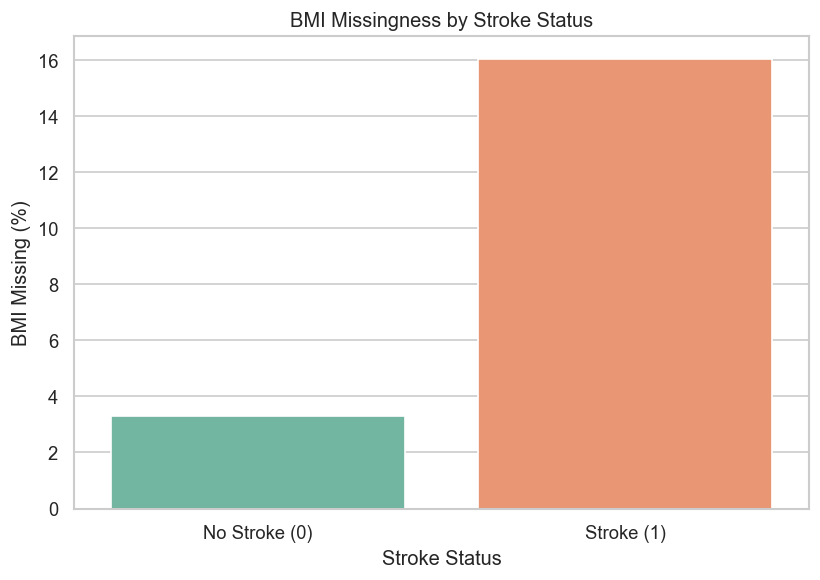

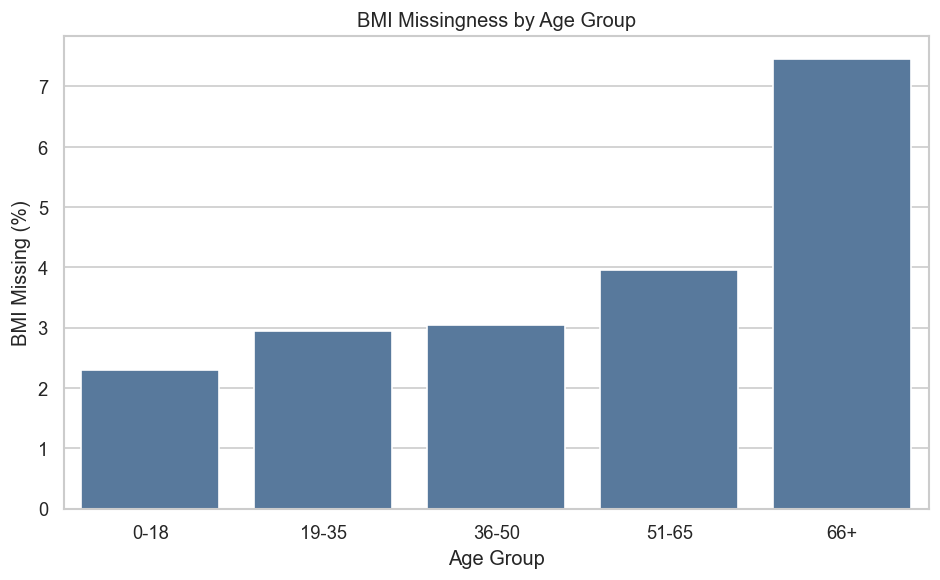

In [4]:
plt.figure(figsize=(7, 5))
sns.barplot(data=missing_by_stroke, x="stroke", y="missing_percentage", hue="stroke", palette="Set2", legend=False)
plt.title("BMI Missingness by Stroke Status")
plt.xlabel("Stroke Status")
plt.ylabel("BMI Missing (%)")
plt.xticks([0, 1], ["No Stroke (0)", "Stroke (1)"])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bmi_missingness_by_stroke.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=missing_by_age_group, x="age_group", y="missing_percentage", color="#4C78A8")
plt.title("BMI Missingness by Age Group")
plt.xlabel("Age Group")
plt.ylabel("BMI Missing (%)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bmi_missingness_by_age_group.png", bbox_inches="tight")
plt.show()

## 5. Create Four Processed Datasets

Four missing-value strategies are applied to the BMI variable:

1. **Delete Rows** removes all records with missing BMI.
2. **Mean Imputation** replaces missing BMI values with the observed mean BMI.
3. **Median Imputation** replaces missing BMI values with the observed median BMI.
4. **KNN Imputation** estimates missing BMI values from nearby records using non-target predictor variables.

The stroke target is not used as a predictor for KNN imputation to avoid target leakage. The goal is to evaluate preprocessing strategies, not to train or optimise a predictive model in this notebook.

In [5]:
delete_rows_df = df.dropna(subset=["bmi"]).copy()

mean_imputation_df = df.copy()
mean_value = df["bmi"].mean()
mean_imputation_df["bmi"] = mean_imputation_df["bmi"].fillna(mean_value)

median_imputation_df = df.copy()
median_value = df["bmi"].median()
median_imputation_df["bmi"] = median_imputation_df["bmi"].fillna(median_value)

knn_imputation_df = df.copy()
knn_predictors = df.drop(columns=["id", "stroke"], errors="ignore")
knn_encoded = pd.get_dummies(knn_predictors, drop_first=False)
knn_columns = knn_encoded.columns

scaler = StandardScaler()
knn_scaled = pd.DataFrame(scaler.fit_transform(knn_encoded), columns=knn_columns, index=df.index)
bmi_index = list(knn_columns).index("bmi")

knn_imputer = KNNImputer(n_neighbors=5, weights="distance")
knn_imputed_scaled = knn_imputer.fit_transform(knn_scaled)
knn_bmi_scaled = knn_imputed_scaled[:, bmi_index]
bmi_mean_for_inverse = scaler.mean_[bmi_index]
bmi_scale_for_inverse = scaler.scale_[bmi_index]
knn_imputation_df["bmi"] = (knn_bmi_scaled * bmi_scale_for_inverse) + bmi_mean_for_inverse

processed_datasets = {
    "delete_rows": delete_rows_df,
    "mean_imputation": mean_imputation_df,
    "median_imputation": median_imputation_df,
    "knn_imputation": knn_imputation_df
}

for name, processed_df in processed_datasets.items():
    processed_df.to_csv(PROCESSED_DIR / f"stroke_{name}.csv", index=False)

print("Processed datasets saved:")
for name in processed_datasets:
    print(PROCESSED_DIR / f"stroke_{name}.csv")

Processed datasets saved:
C:\Users\11315\Documents\Stroke_Project\data\processed\stroke_delete_rows.csv
C:\Users\11315\Documents\Stroke_Project\data\processed\stroke_mean_imputation.csv
C:\Users\11315\Documents\Stroke_Project\data\processed\stroke_median_imputation.csv
C:\Users\11315\Documents\Stroke_Project\data\processed\stroke_knn_imputation.csv


## 6. Compare Dataset Size and Missingness After Processing

A central trade-off in missing-value handling is between retaining the full dataset and preserving the original observed distribution. Row deletion retains only complete BMI records, while imputation methods preserve the sample size but add estimated values.

In [6]:
sample_comparison = []
for method, processed_df in processed_datasets.items():
    sample_comparison.append({
        "method": method,
        "rows": len(processed_df),
        "rows_removed": len(df) - len(processed_df),
        "bmi_missing_after_processing": processed_df["bmi"].isna().sum(),
        "stroke_cases": int(processed_df["stroke"].sum()),
        "stroke_percentage": round(processed_df["stroke"].mean() * 100, 2)
    })

sample_comparison = pd.DataFrame(sample_comparison)
sample_comparison.to_csv(TABLES_DIR / "missing_value_method_sample_comparison.csv", index=False)
display(sample_comparison)

,method,rows,rows_removed,bmi_missing_after_processing,stroke_cases,stroke_percentage
0,delete_rows,4909,201,0,209,4.26
1,mean_imputation,5110,0,0,249,4.87
2,median_imputation,5110,0,0,249,4.87
3,knn_imputation,5110,0,0,249,4.87


## 7. Compare BMI Distributions Before and After Imputation

Distributional comparison is used to evaluate how much each method changes the BMI variable. A suitable imputation method should remove missingness while avoiding excessive distortion of the observed BMI distribution.

In [7]:
observed_bmi = df["bmi"].dropna()
distribution_rows = [{
    "method": "observed_original",
    "count": observed_bmi.count(),
    "mean": observed_bmi.mean(),
    "median": observed_bmi.median(),
    "std": observed_bmi.std(),
    "min": observed_bmi.min(),
    "q1": observed_bmi.quantile(0.25),
    "q3": observed_bmi.quantile(0.75),
    "max": observed_bmi.max()
}]

for method, processed_df in processed_datasets.items():
    bmi = processed_df["bmi"]
    distribution_rows.append({
        "method": method,
        "count": bmi.count(),
        "mean": bmi.mean(),
        "median": bmi.median(),
        "std": bmi.std(),
        "min": bmi.min(),
        "q1": bmi.quantile(0.25),
        "q3": bmi.quantile(0.75),
        "max": bmi.max()
    })

bmi_distribution_comparison = pd.DataFrame(distribution_rows).round(3)
bmi_distribution_comparison.to_csv(TABLES_DIR / "bmi_distribution_comparison.csv", index=False)
display(bmi_distribution_comparison)

,method,count,mean,median,std,min,q1,q3,max
0,observed_original,4909,28.893,28.1,7.854,10.3,23.5,33.1,97.6
1,delete_rows,4909,28.893,28.1,7.854,10.3,23.5,33.1,97.6
2,mean_imputation,5110,28.893,28.4,7.698,10.3,23.8,32.8,97.6
3,median_imputation,5110,28.862,28.1,7.700,10.3,23.8,32.8,97.6
4,knn_imputation,5110,28.945,28.2,7.781,10.3,23.7,33.1,97.6


## 8. Distribution Comparison Figures

The following figures compare BMI distributions across the original observed data and each processed dataset. Histograms show distribution shape, while boxplots make shifts in median, spread, and outliers easier to inspect.

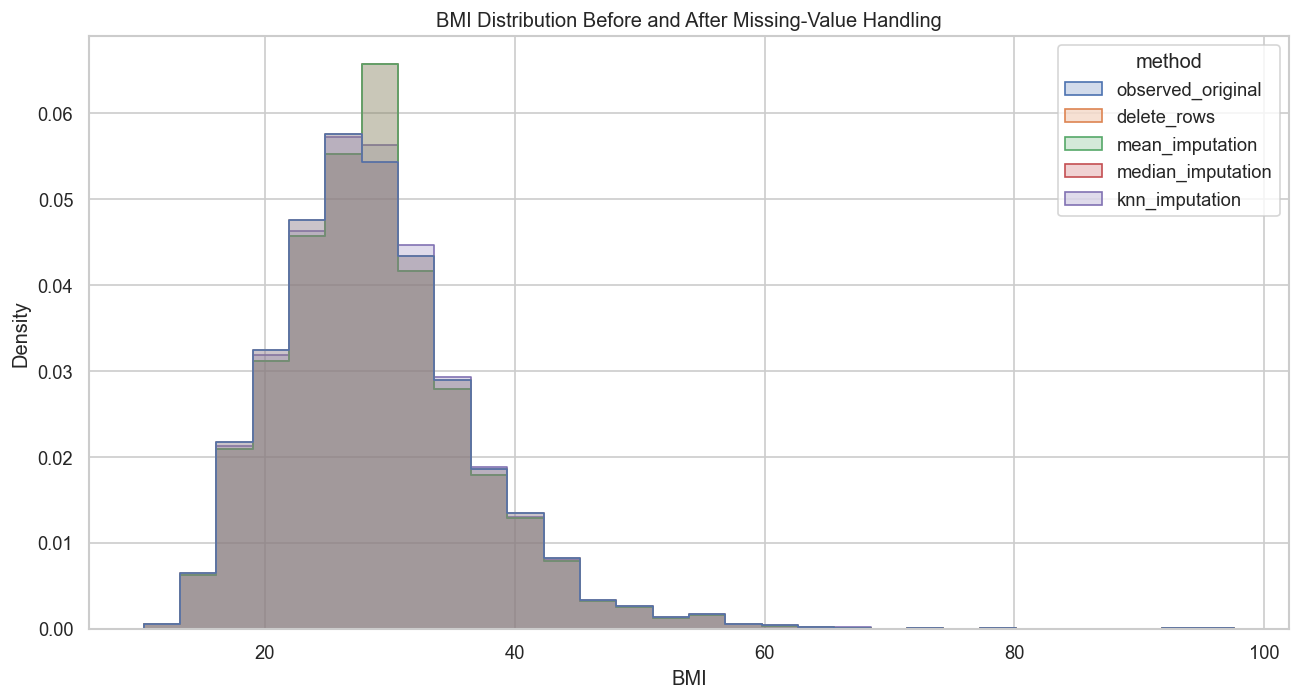

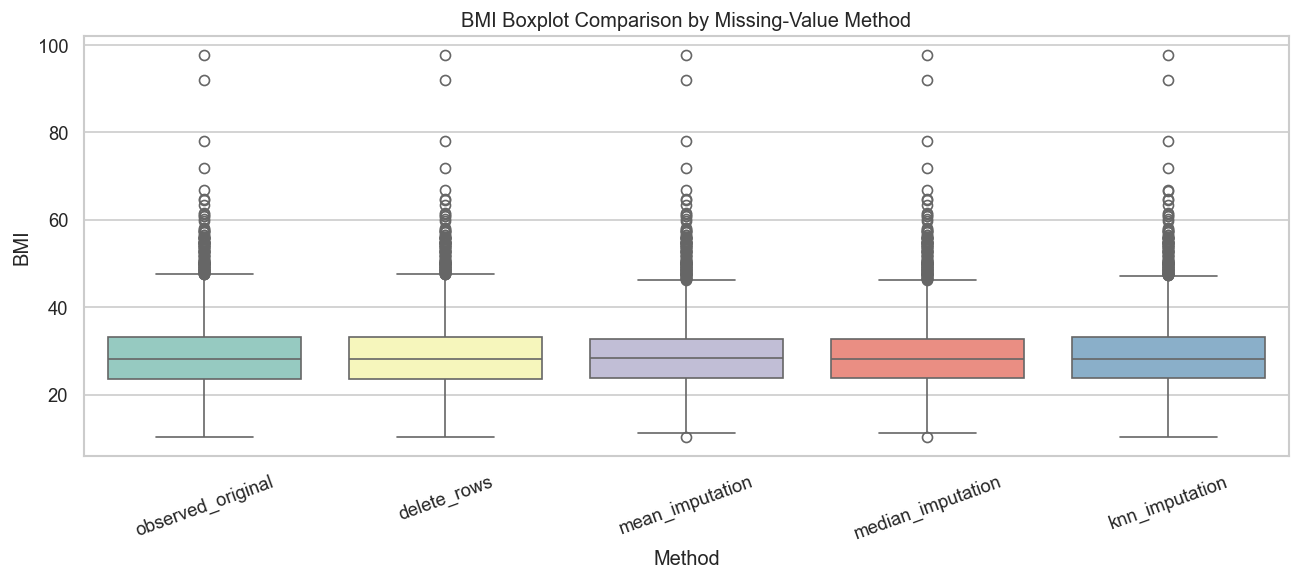

In [8]:
plot_frames = [pd.DataFrame({"method": "observed_original", "bmi": observed_bmi})]
for method, processed_df in processed_datasets.items():
    plot_frames.append(pd.DataFrame({"method": method, "bmi": processed_df["bmi"]}))

bmi_long = pd.concat(plot_frames, ignore_index=True)

plt.figure(figsize=(11, 6))
sns.histplot(data=bmi_long, x="bmi", hue="method", element="step", stat="density", common_norm=False, bins=30)
plt.title("BMI Distribution Before and After Missing-Value Handling")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bmi_distribution_imputation_comparison.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(11, 5))
sns.boxplot(data=bmi_long, x="method", y="bmi", hue="method", palette="Set3", legend=False)
plt.title("BMI Boxplot Comparison by Missing-Value Method")
plt.xlabel("Method")
plt.ylabel("BMI")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bmi_boxplot_imputation_comparison.png", bbox_inches="tight")
plt.show()

## 9. Compare Imputed Values Directly

Only the originally missing BMI records are used in this comparison. This isolates the values introduced by each imputation method and helps assess whether a method produces overly uniform or implausibly variable replacements.

,count,mean,std,min,25%,50%,75%,max
mean_imputation,201.0,28.893,0.000,28.893,28.893,28.893,28.893,28.893
median_imputation,201.0,28.100,0.000,28.100,28.100,28.100,28.100,28.100
knn_imputation,201.0,30.204,5.589,16.460,27.569,30.017,32.896,66.502


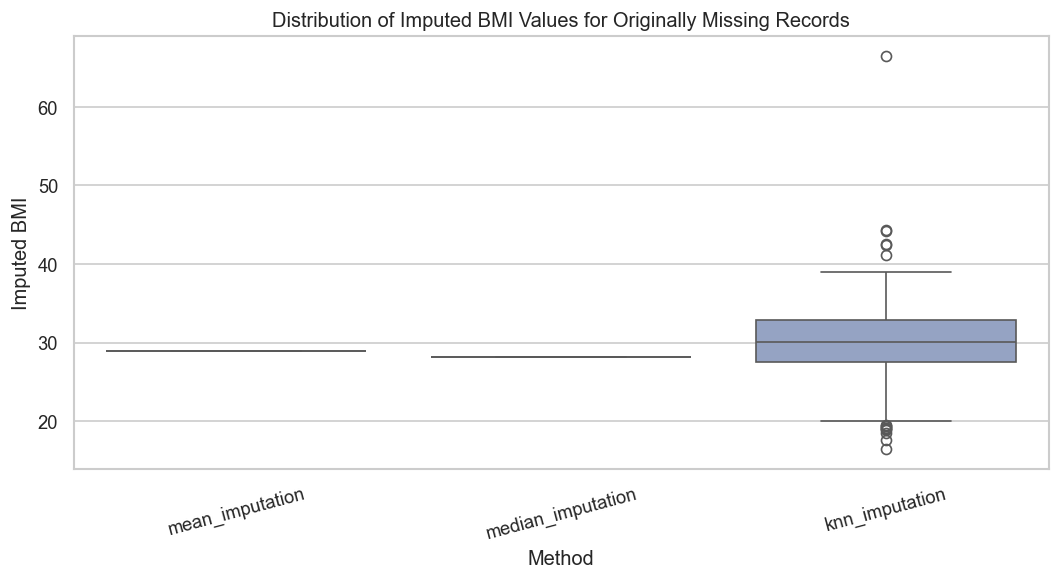

In [9]:
missing_bmi_index = df.index[df["bmi"].isna()]
imputed_values = pd.DataFrame({
    "mean_imputation": mean_imputation_df.loc[missing_bmi_index, "bmi"],
    "median_imputation": median_imputation_df.loc[missing_bmi_index, "bmi"],
    "knn_imputation": knn_imputation_df.loc[missing_bmi_index, "bmi"]
})

imputed_values_summary = imputed_values.describe().T.round(3)
imputed_values_summary.to_csv(TABLES_DIR / "imputed_bmi_values_summary.csv")
display(imputed_values_summary)

plt.figure(figsize=(9, 5))
sns.boxplot(data=imputed_values, palette="Set2")
plt.title("Distribution of Imputed BMI Values for Originally Missing Records")
plt.xlabel("Method")
plt.ylabel("Imputed BMI")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "imputed_bmi_values_comparison.png", bbox_inches="tight")
plt.show()

## 10. Method Comparison Table

The table below summarises the practical and methodological implications of each missing-value strategy. This supports transparent selection of a recommended approach for later preprocessing.

In [10]:
method_comparison = pd.DataFrame([
    {
        "method": "Delete Rows",
        "advantages": "Simple, transparent, uses only observed BMI values, no imputation assumptions.",
        "disadvantages": "Reduces sample size and may bias the dataset if BMI missingness is associated with patient characteristics.",
        "suitability": "Useful as a sensitivity analysis, but not preferred as the primary method."
    },
    {
        "method": "Mean Imputation",
        "advantages": "Simple, reproducible, preserves all rows, easy to explain.",
        "disadvantages": "Sensitive to outliers and can reduce variance by replacing all missing values with the same mean.",
        "suitability": "Acceptable only as a basic benchmark; less robust for skewed clinical variables."
    },
    {
        "method": "Median Imputation",
        "advantages": "Simple, robust to outliers, preserves all rows, suitable when BMI is skewed.",
        "disadvantages": "Still creates repeated values and does not use relationships with other variables.",
        "suitability": "Recommended primary method for this project because it balances robustness, interpretability, and sample retention."
    },
    {
        "method": "KNN Imputation",
        "advantages": "Uses multivariable similarity and can produce more individualised BMI estimates.",
        "disadvantages": "More complex, sensitive to scaling and feature choice, less transparent, and can be computationally heavier.",
        "suitability": "Useful as a secondary comparison method, but less transparent for the main dissertation pipeline."
    }
])

method_comparison.to_csv(TABLES_DIR / "missing_value_method_comparison.csv", index=False)
display(method_comparison)

,method,advantages,disadvantages,suitability
0,Delete Rows,"Simple, transparent, uses only observed BMI va...",Reduces sample size and may bias the dataset i...,"Useful as a sensitivity analysis, but not pref..."
1,Mean Imputation,"Simple, reproducible, preserves all rows, easy...",Sensitive to outliers and can reduce variance ...,Acceptable only as a basic benchmark; less rob...
2,Median Imputation,"Simple, robust to outliers, preserves all rows...",Still creates repeated values and does not use...,Recommended primary method for this project be...
3,KNN Imputation,Uses multivariable similarity and can produce ...,"More complex, sensitive to scaling and feature...","Useful as a secondary comparison method, but l..."


## 11. Recommended Method

Based on this missing-value analysis, **median imputation is recommended as the primary BMI missing-value handling method** for the next stage of the project.

Median imputation is recommended because it preserves the full sample size while remaining robust to skewness and potential outliers in BMI. This is important in a stroke prediction dataset, where removing records may reduce the already limited number of positive stroke cases and may alter the class distribution. Compared with mean imputation, median imputation is less affected by extreme BMI values. Compared with KNN imputation, it is more transparent, easier to reproduce, and easier to justify in a dissertation methodology section.

KNN imputation remains valuable as a comparison technique because it uses information from other variables to estimate missing BMI values. However, its results depend on feature scaling, the selected predictors, and the number of neighbours. For this reason, it introduces additional methodological complexity without necessarily providing enough transparency for the primary preprocessing pipeline.

Row deletion is not recommended as the primary method because it discards patient records and may change the dataset composition. Mean imputation is also not recommended as the main method because it is sensitive to outliers and can artificially reduce the variability of BMI.

## 12. Advantages and Disadvantages Summary

**Delete Rows**

Advantages: It is simple, transparent, and avoids creating artificial BMI values. It can be useful as a sensitivity check because it uses only complete observations.

Disadvantages: It reduces the dataset size and may remove clinically important records. If BMI missingness is not random, deletion can introduce bias and alter the class distribution.

**Mean Imputation**

Advantages: It is easy to implement, preserves all observations, and provides a clear baseline imputation approach.

Disadvantages: It is sensitive to outliers and can distort the BMI distribution by pulling missing values toward the arithmetic mean. It also underestimates natural variability because all missing observations receive the same value.

**Median Imputation**

Advantages: It preserves the full sample, is robust to outliers, and is appropriate when a variable is skewed. It is also easy to explain and reproduce.

Disadvantages: It does not use information from other variables and can create an artificial concentration of records at the median value.

**KNN Imputation**

Advantages: It uses similarity across multiple patient characteristics and can generate more individualised imputed BMI values than mean or median imputation.

Disadvantages: It is more complex, depends on feature scaling and predictor selection, and is less transparent. It can also be harder to justify if the imputation process is not carefully documented.

Overall, median imputation provides the best balance of methodological robustness, interpretability, and practical suitability for the next preprocessing stage of this stroke prediction project.